# Отчет к лабораторной работе

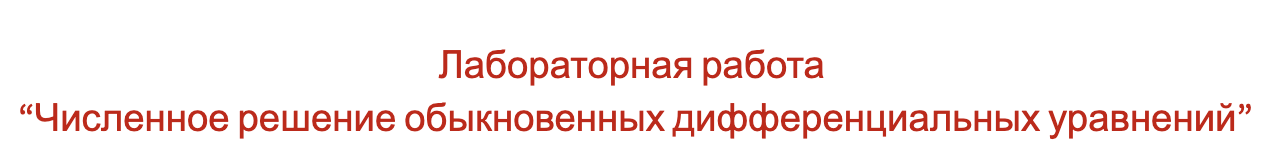

Шуман Владислав Олегович

3 курс 4 группа 

вариант 9-11

корневая директория с лабораторной работой Github

[Github](https://github.com/UladzislauShuman/university_homework/tree/main/famcs_homework/numerical_methods/6sem/lab4)

в ней лежат 
- исходный код в файле ipynb
- /отчет 
- /условие (pdf или nb) и /теория (вырванные из контекста главы конспектов)

Дата последних изменений: 24 мая 2026

# Условие

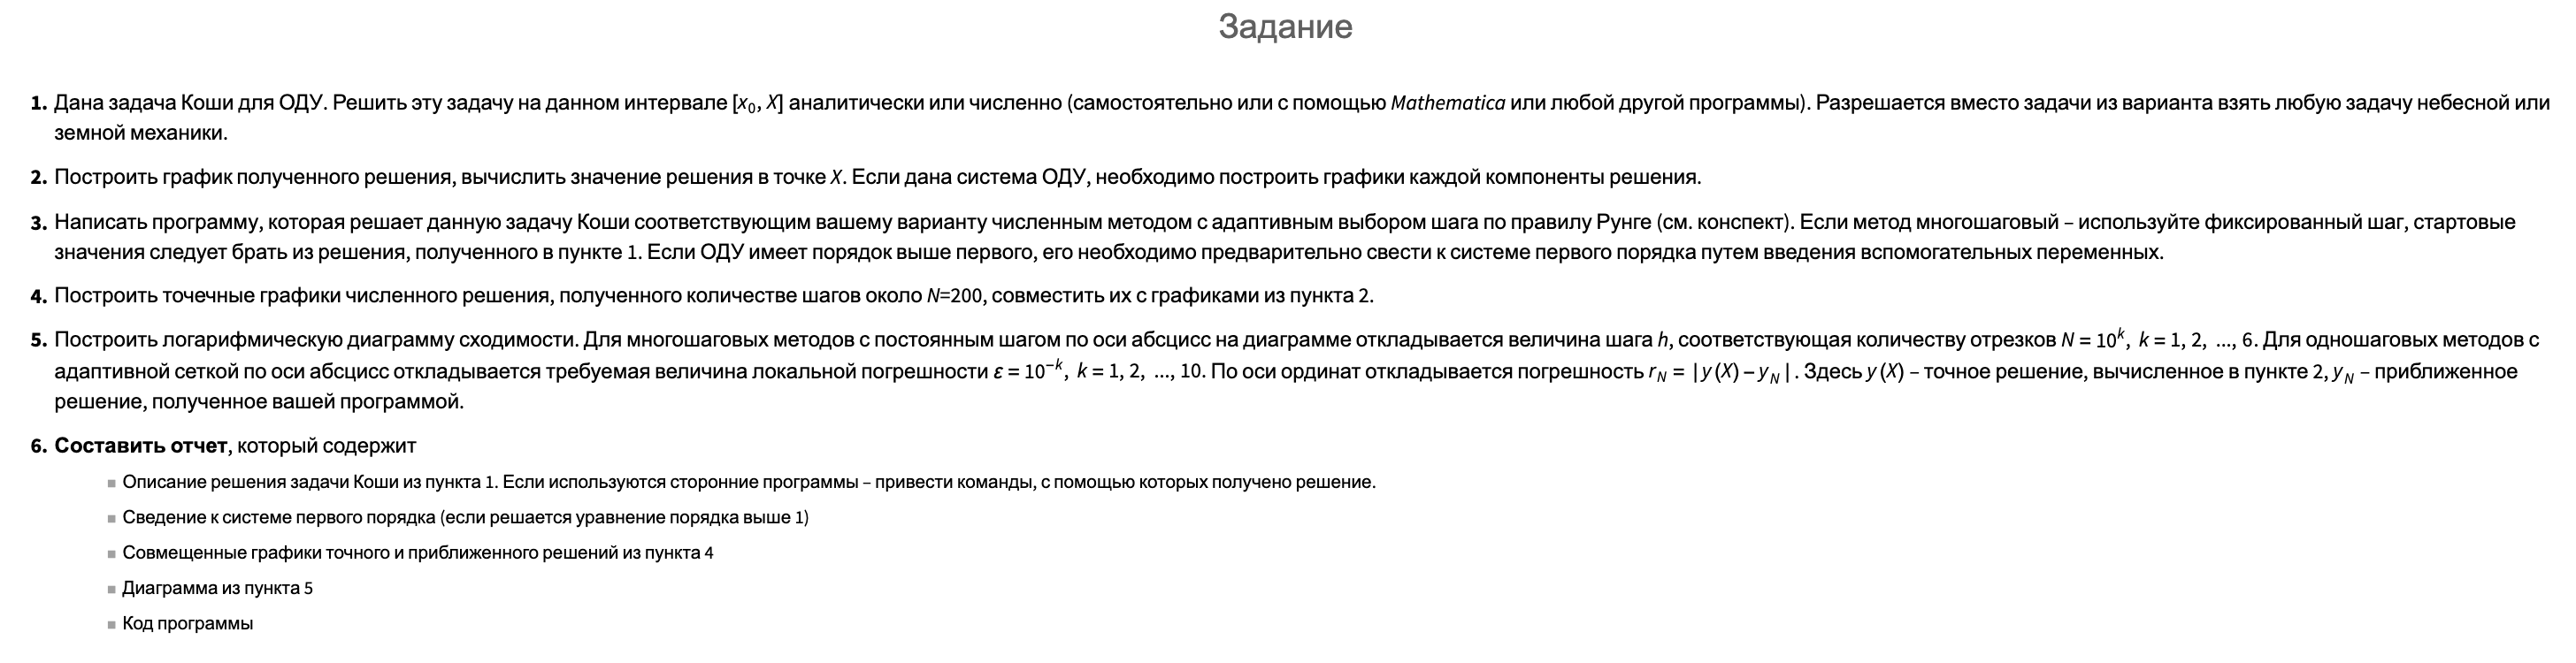

Метод: 9

Задача: 11

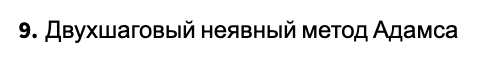

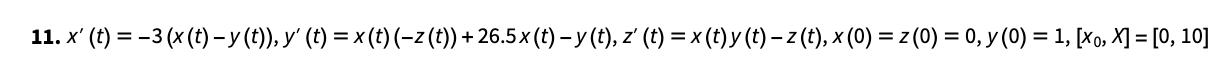

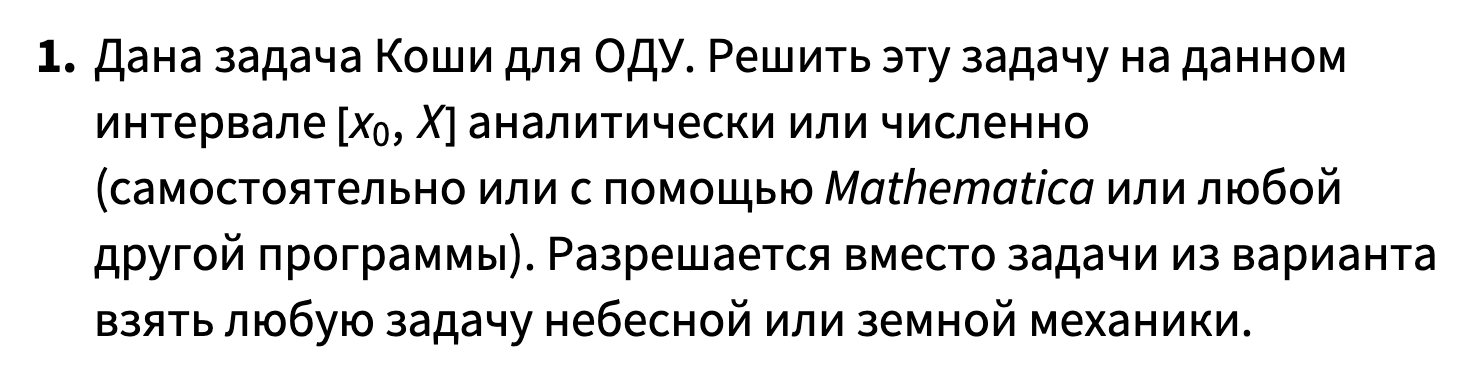

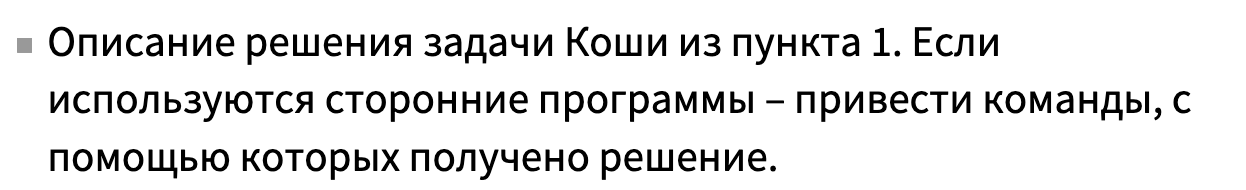


$$[t_0, T] = [0, 10]$$

$$
\begin{cases}
x'(t) = -3 (x(t) - y(t)) \\
y'(t) = x(t) (-z(t)) + 26.5 x(t) - y(t) \\
z'(t) = x(t) y(t) - z(t)
\end{cases}
$$
    
$$x(0) = 0, \quad y(0) = 1, \quad z(0) = 0$$

$$T = 10$$

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# правая часть системы
def function(t, u):
    x, y, z = u
    dxdt = -3 * (x - y)
    dydt = x * (-z) + 26.5 * x - y
    dzdt = x * y - z
    return np.array([dxdt, dydt, dzdt])

# решение системы на интвервале
sol = solve_ivp(
    function, # наша правая часть
    [0, 10], # интервал
    [0, 1, 0], # начальные условия
    rtol=1e-12, # относительная
    atol=1e-12 # абсолютная погрещности
)

# значание в точке 10
x_end, y_end, z_end = sol.y[:, -1]

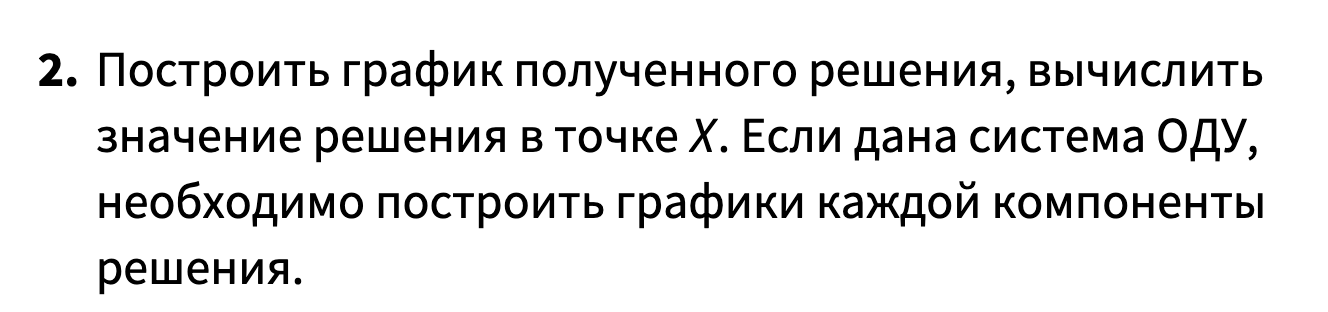

In [ ]:
print(f"x(10) = {x_end:.12f}")
print(f"y(10) = {y_end:.12f}")
print(f"z(10) = {z_end:.12f}")

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label="x(t)", color="blue", linewidth=2)
plt.plot(sol.t, sol.y[1], label="y(t)", color="red", linewidth=2)
plt.plot(sol.t, sol.y[2], label="z(t)", color="green", linewidth=2)
plt.xlabel("t")
plt.ylabel("решение")
plt.title("графики каждой компоненты")
plt.legend()
plt.grid(True)
plt.show()

x(10) = -1.665775403729 

y(10) = -0.734529120469 

z(10) = 20.378666398905

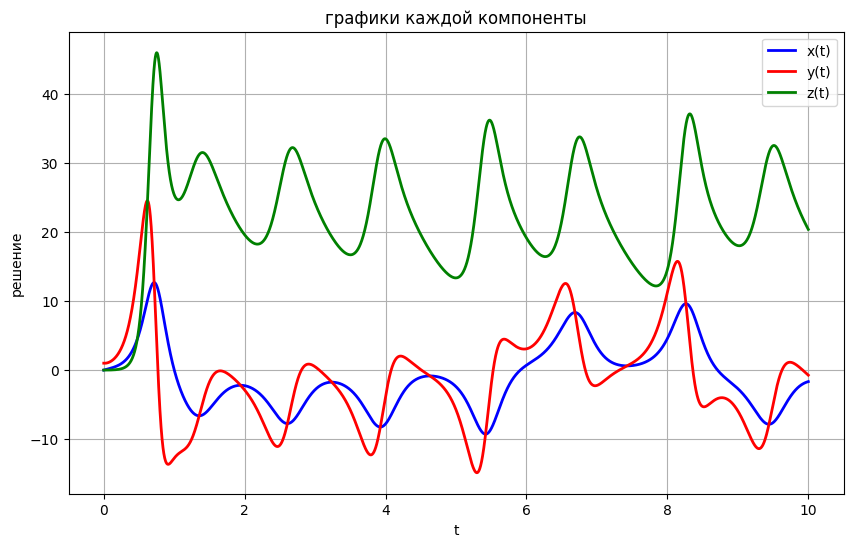

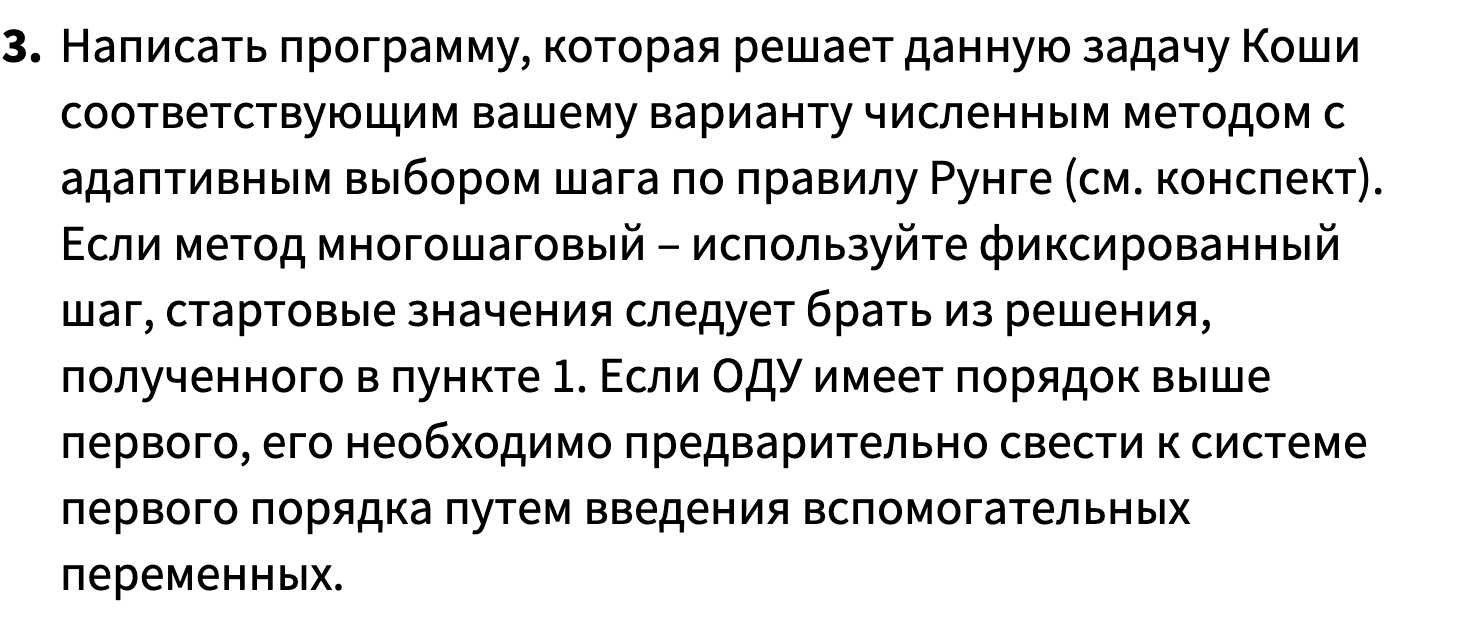

Мой метод

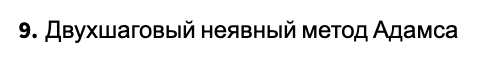

фрагменты теории, на которые я хочу сослаться

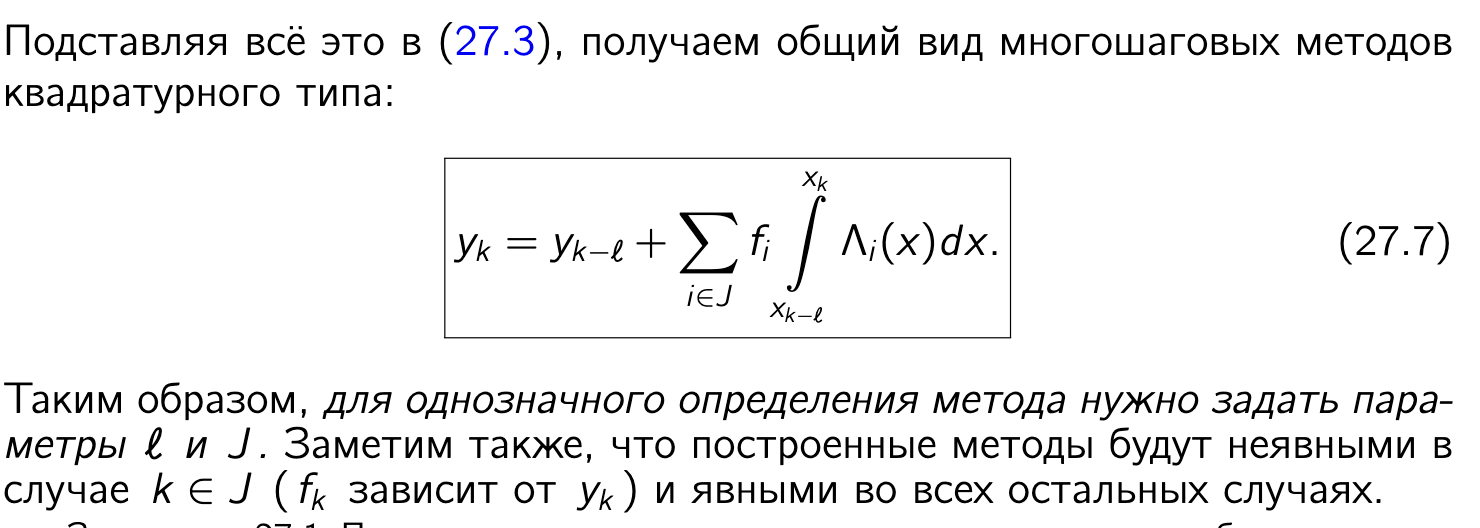

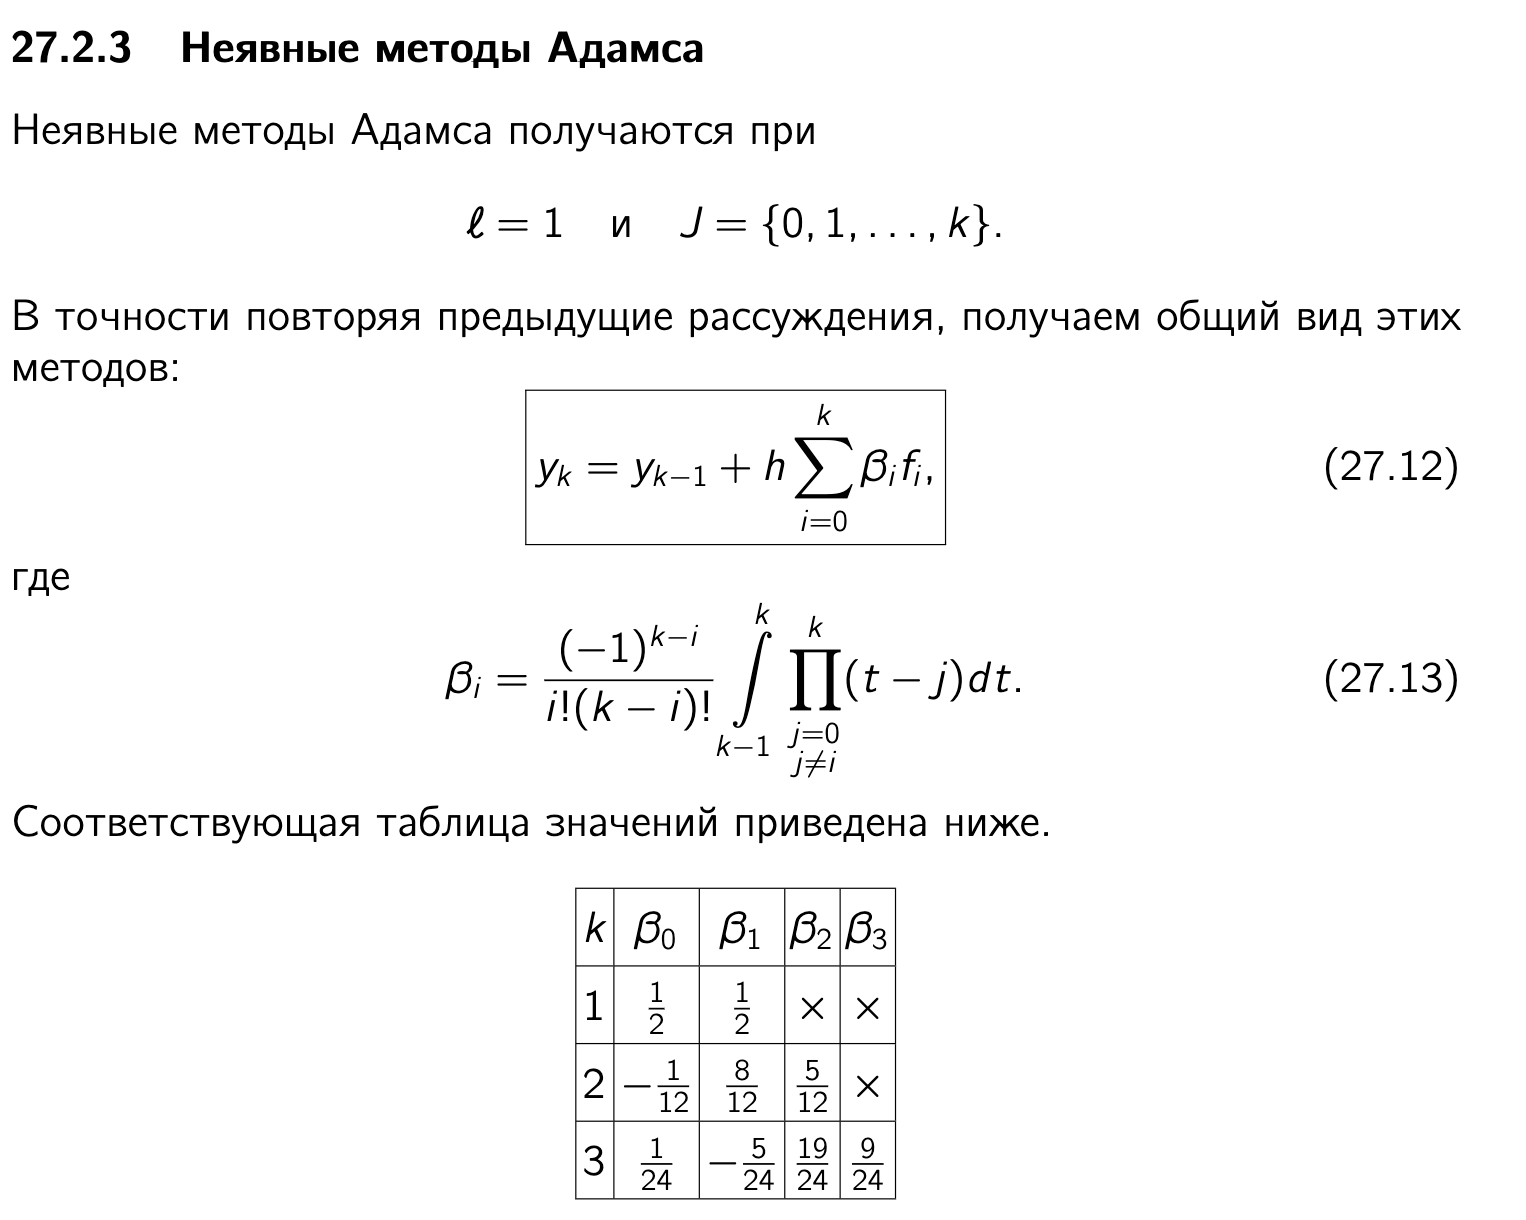

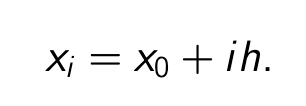

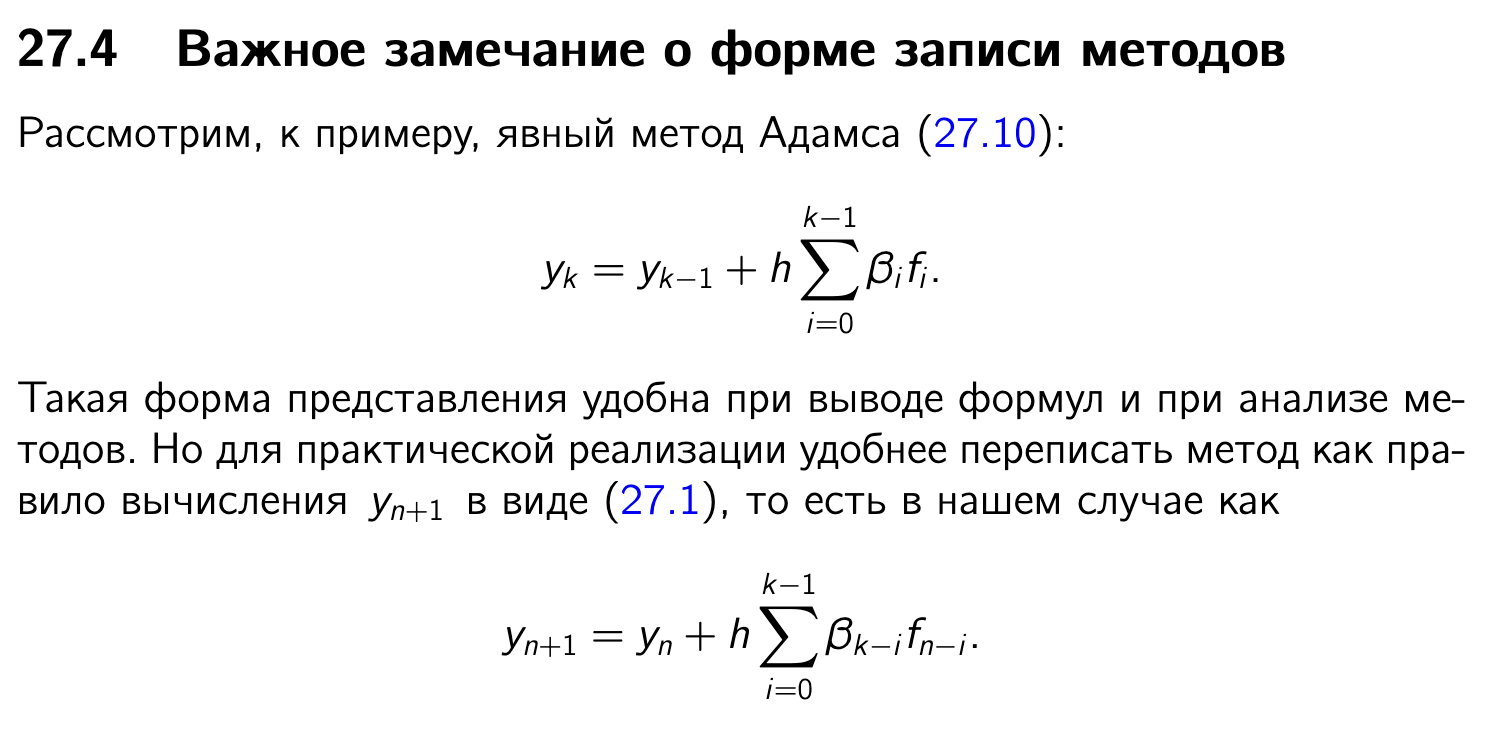

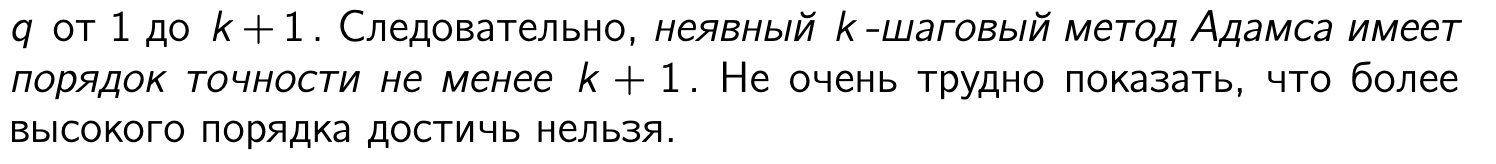

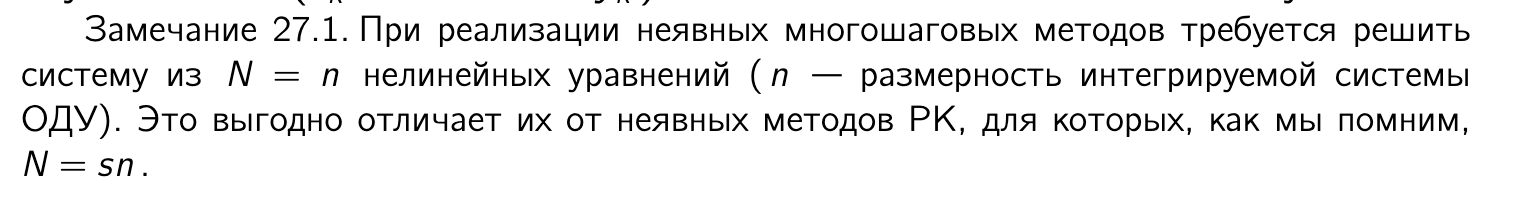

$$\vec{u}(t) = \begin{bmatrix} x(t) \\ y(t) \\ z(t) \end{bmatrix}$$

In [ ]:
# u0 и u1 получить
def get_starting_values(step_size):
    u0 = np.array([0.0, 1.0, 0.0])
    ref_solve = solve_ivp(
        function, 
        [0, step_size], 
        u0, 
        t_eval=[step_size],
        rtol=1e-12, 
        atol=1e-12
    )
    u1 = ref_solve.y[:, 0].flatten()
    return u0, u1

from scipy.optimize import fsolve # для решения НСУ

# функция метода
def implicit_adams_2step(step_size, num_steps):
    t_values = np.linspace(0, 10, num_steps + 1) # разбит [0,10] на num_steps + 1
    u_values = np.zeros((num_steps + 1, 3)) # u0, u1, ... u_n+1
    
    # заносим начальные
    u_values[0], u_values[1] = get_starting_values(step_size)
    
    # правые части
    f_values = np.zeros((num_steps + 1, 3)) # f0, f1, f2, ...
    f_values[0] = function(t_values[0], u_values[0])
    f_values[1] = function(t_values[1], u_values[1])
    
    for n in range(1, num_steps):
        # НСУ чтобы найти u_n+1
        def equations_system(u_n_plus_one):
            f_n_plus_one = function(t_values[n+1], u_n_plus_one)
            # разность Л и П из (27.12)
            return u_n_plus_one - u_values[n] - (step_size / 12.0) * (5 * f_n_plus_one + 8 * f_values[n] - f_values[n-1])
        
        u_values[n+1] = fsolve(equations_system, u_values[n]) # u_n+1
        f_values[n+1] = function(t_values[n+1], u_values[n+1]) # f_n+1
        
    return t_values, u_values

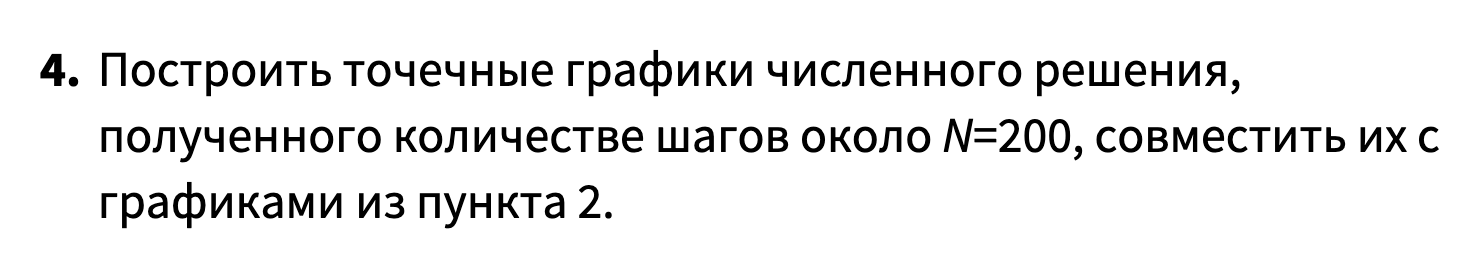

In [ ]:
# константы
num_steps_plot = 200
step_size_plot = 10.0 / num_steps_plot

# численное решение нашим методом
t_adams, u_adams = implicit_adams_2step(step_size_plot, num_steps_plot)

# построение совмещенных графиков
plt.figure(figsize=(12, 8))

# пункт 2
plt.plot(sol.t, sol.y[0], label="x(t) пункт 2", color="blue", linewidth=1.5, alpha=0.6)
plt.plot(sol.t, sol.y[1], label="y(t) пункт 2", color="red", linewidth=1.5, alpha=0.6)
plt.plot(sol.t, sol.y[2], label="z(t) пункт 2", color="green", linewidth=1.5, alpha=0.6)

# точки нашего метода
plt.scatter(t_adams, u_adams[:, 0], label="x(t) наш", color="blue", marker="o", s=8)
plt.scatter(t_adams, u_adams[:, 1], label="y(t) наш", color="red", marker="x", s=8)
plt.scatter(t_adams, u_adams[:, 2], label="z(t) наш", color="green", marker="^", s=8)

# оформление графика
plt.xlabel("t")
plt.ylabel("решение")
plt.title(f"пункт 4 (N = {num_steps_plot})")
plt.legend()
plt.grid(True)
plt.show()

как видно из графика, 

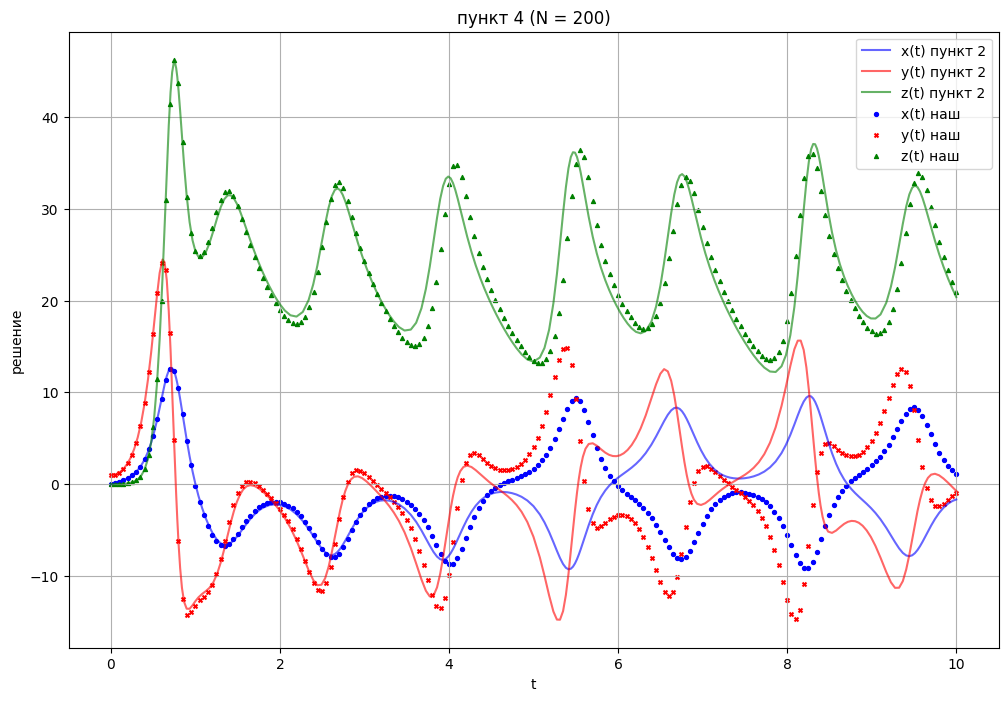

точки хорошо ложатся на график только до $t = 4$, а далее начинает симметрично отражаться приблизительно относительно $x = 0$. при чем -- при $N = 500$ все намного лучше

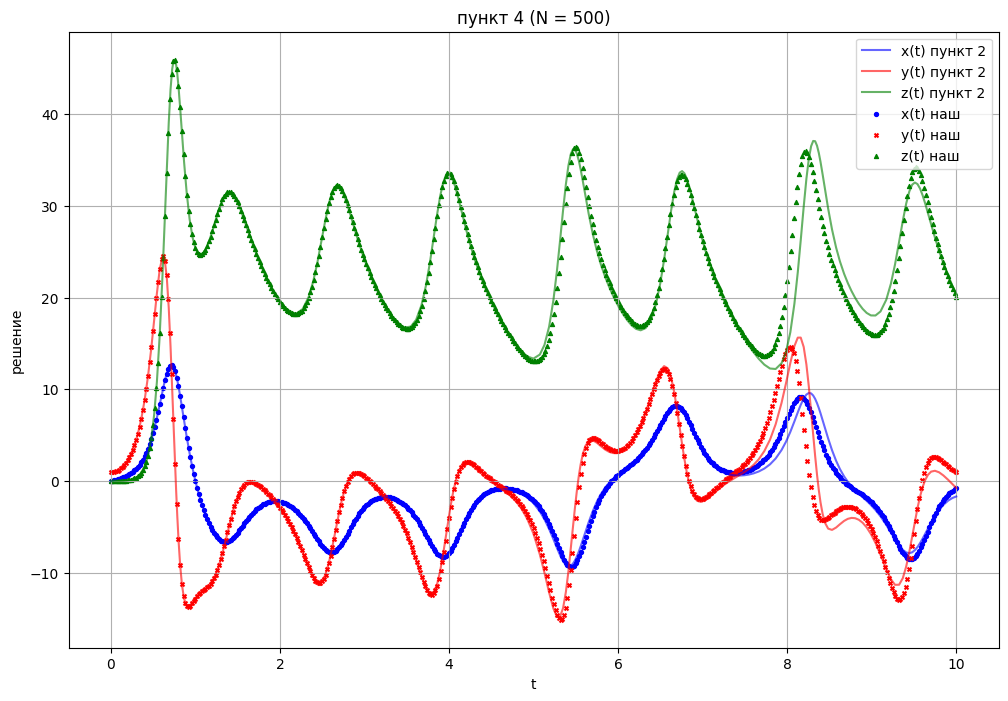

с чем это связано?
- методы Адамса нуль-устойчивы
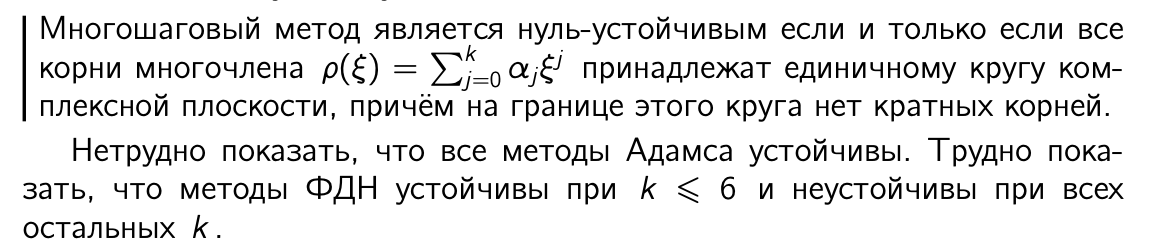
- глобальной ошибкой и как h влияет на это
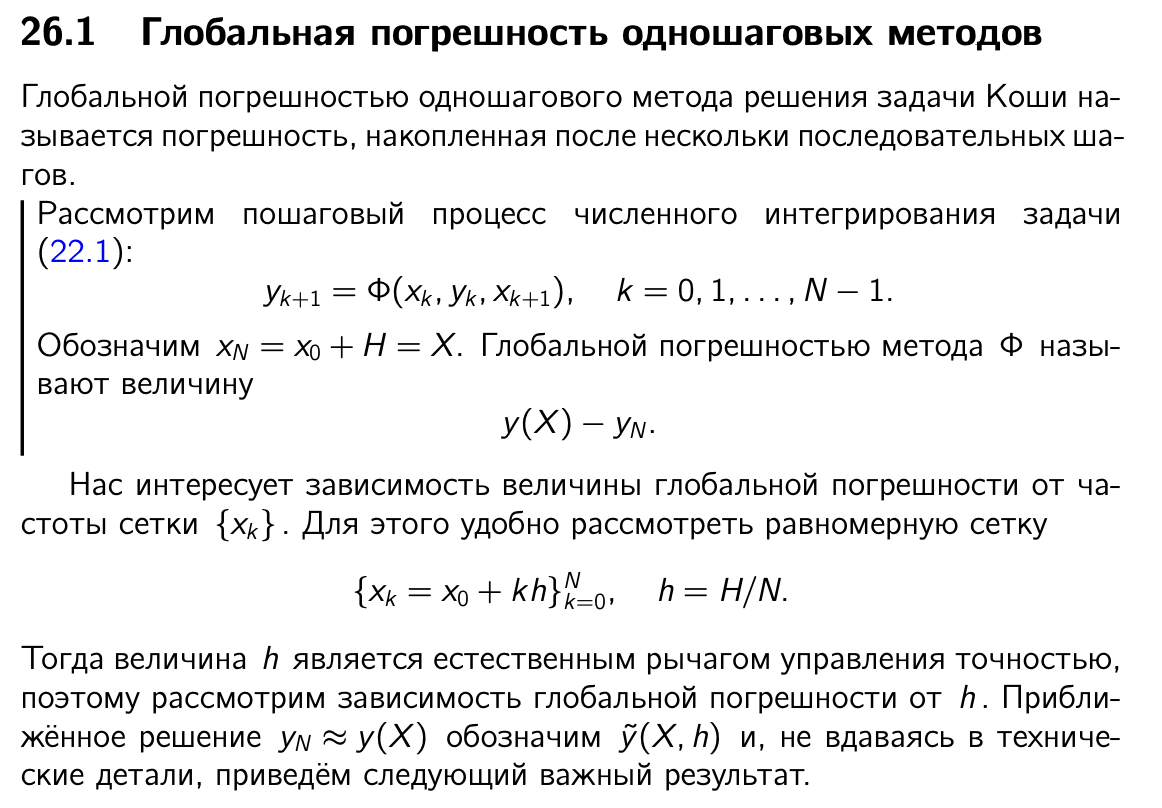
- если подставить $-x$ и $-y$ вместо $x$ и $y$, то получим симметрию: $(x, y, z) -> (-x, -y, z)$, то есть -- тоже является решением



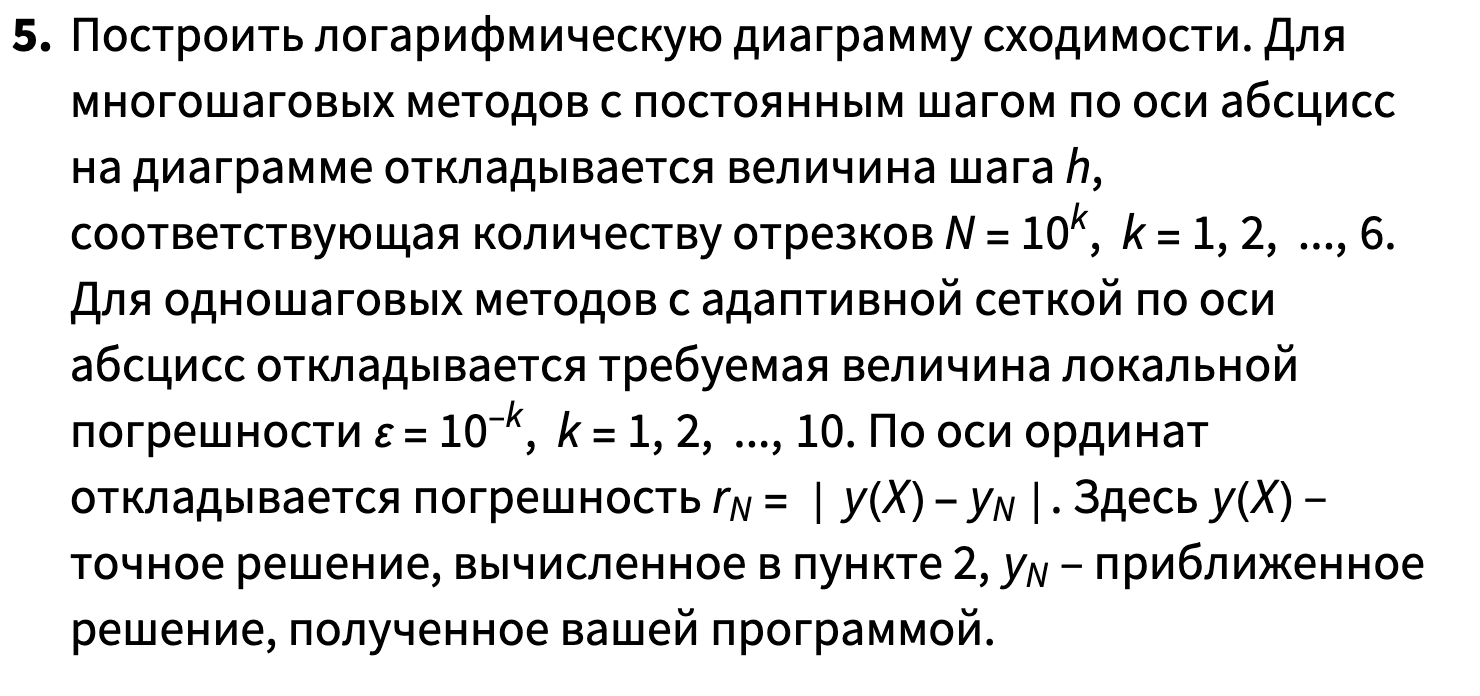

In [ ]:
# эталон
u_exact_end = np.array([x_end, y_end, z_end])

# для сохранения шагов и погрешностей
step_sizes = []
errors = []

# число шагов N = 10^k
k_values = [1, 2, 3, 4, 5, 6]

for k in k_values:
    num_steps_calc = 10**k
    step_size_calc = 10.0 / num_steps_calc
    
    # решаем
    _, u_calc = implicit_adams_2step(step_size_calc, num_steps_calc)
    u_calc_end = u_calc[-1]
    
    # погрешность в конечной точке
    error_norm = np.linalg.norm(u_exact_end - u_calc_end)
    
    step_sizes.append(step_size_calc)
    errors.append(error_norm)
    
    print(f"N = {num_steps_calc:7d} | h = {step_size_calc:8.6f} | err = {error_norm:.2e}")

# построение логарифмической диаграммы сходимости
plt.figure(figsize=(10, 6))
plt.loglog(step_sizes, errors, "o-", color="purple", linewidth=2, label="погрешность")

# O(h^3)
ref_slope = [h**3 * (errors[-1] / (step_sizes[-1]**3)) for h in step_sizes]
plt.loglog(step_sizes, ref_slope, "--", color="gray", label="O(h^3)")

plt.xlabel("величина шага h")
plt.ylabel("погрешность rN")
plt.title("логарифмическая диаграмма сходимости")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

N =      10 | h = 1.000000 | err = 2.71e+02 

N =     100 | h = 0.100000 | err = 3.09e+00 

N =    1000 | h = 0.010000 | err = 2.55e-01 

N =   10000 | h = 0.001000 | err = 2.59e-04 

N =  100000 | h = 0.000100 | err = 2.62e-07 

N = 1000000 | h = 0.000010 | err = 3.32e-09

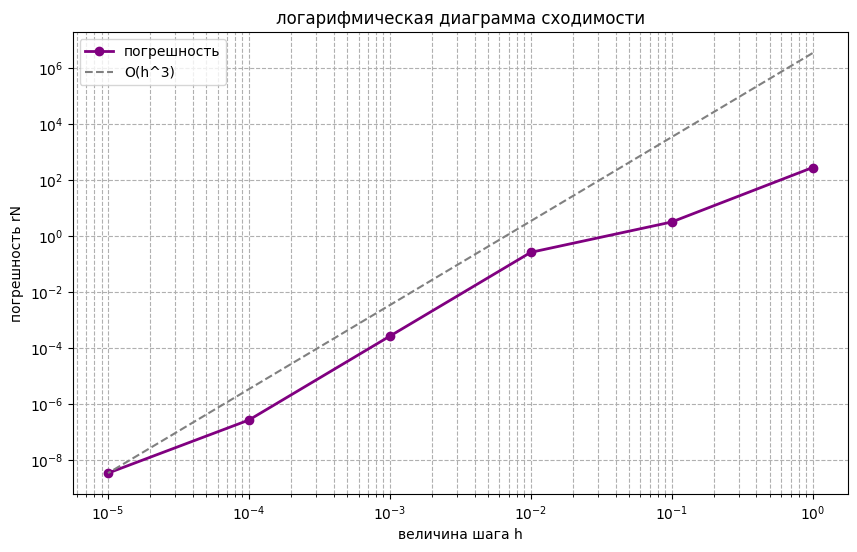

исходя из графика видно
- чем меньше шаг (то есть -- чем больше N), тем меньше погрешность
- порядок точности метода соответсвует/близок к теоретическому (2-шаговый, то есть p = 2 + 1 = 3)